In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import LiqFunDobPen as lf
import ParametersLiq as lp

In [2]:
df = pd.read_csv("double_pendulum_dataset.csv") # Charge the csv(DATA)
# We have to turn it into an array
data = df.values
# Separate inputs and outputs
X = data[:, :4] # Inputs
Y = data[:, 4:] # Outputs

In [3]:
# Computation of the mean and std 
X_mean, X_std = lf.compute_stats(X)
Y_mean, Y_std = lf.compute_stats(Y)
# Normalization
X_norm = lf.norm(X, X_mean, X_std)
Y_norm = lf.norm(Y, Y_mean, Y_std)

In [4]:
# We need time sequences
X_seq = []
Y_seq = []
for i in range(len(X)-lp.seq_len):
    X_seq.append(X_norm[i:i+lp.seq_len])
    Y_seq.append(Y_norm[i:i+lp.seq_len])
X_seq = np.array(X_seq)
Y_seq = np.array(Y_seq)

In [5]:
# Training loop implementing classical ADAM optimizer by hand
net = lf.LiquidNetwork(
    input_size=X.shape[1],
    hidden_size=lp.hidden_size,
    output_size=Y.shape[1]
)



# ===== MOMENTOS =====
m_W_in = np.zeros_like(net.W_in)
m_W_rec = np.zeros_like(net.W_rec)
m_W_out = np.zeros_like(net.W_out)
m_bias = np.zeros_like(net.bias)
m_b_out = np.zeros_like(net.bias_out)

v_W_in = np.zeros_like(net.W_in)
v_W_rec = np.zeros_like(net.W_rec)
v_W_out = np.zeros_like(net.W_out)
v_bias = np.zeros_like(net.bias)
v_b_out = np.zeros_like(net.bias_out)

t_adam = 0


# ===== TRAINING =====
for epoch in range(lp.epochs):

    total_loss = 0
    lr = lp.initial_lr * (0.95 ** epoch)


    # shuffle (muy recomendable)
    indices = np.random.permutation(len(X_seq))

    for i in indices:

        net.reset()

        states = []
        outputs = []
        inputs = []
        targets = []

        loss = 0

        # ========= FORWARD =========
        for t in range(len(X_seq[i])):

            x_t = X_seq[i, t]
            y_t = Y_seq[i, t]

            y_pred = net.step(x_t)

            states.append(net.state.copy())
            outputs.append(y_pred)
            inputs.append(x_t)
            targets.append(y_t)

            loss += lf.mse_loss(y_pred, y_t)

        # ========= BACKWARD (BPTT) =========
        grad_W_in = np.zeros_like(net.W_in)
        grad_W_rec = np.zeros_like(net.W_rec)
        grad_W_out = np.zeros_like(net.W_out)
        grad_bias = np.zeros_like(net.bias)
        grad_b_out = np.zeros_like(net.bias_out)

        grad_state_next = np.zeros(net.hidden_size)

        for t in reversed(range(len(states))):

            state_t = states[t]
            input_t = inputs[t]
            y_pred = outputs[t]
            y_true = targets[t]

            # grad loss
            grad_y = lf.mse_grad(y_pred, y_true)

            # OUTPUT LAYER
            grad_W_out += np.outer(grad_y, state_t)
            grad_b_out += grad_y

            grad_state = net.W_out.T @ grad_y
            grad_state += grad_state_next

            # RECOMPUTAR DINÁMICA
            z = net.W_in @ input_t + net.W_rec @ state_t + net.bias
            tanh_z = np.tanh(z)
            dtanh = 1 - tanh_z**2

            grad = dtanh * grad_state

            # GRADIENTES
            grad_W_rec += np.outer(grad, state_t)
            grad_W_in += np.outer(grad, input_t)
            grad_bias += grad

            # BACKPROP TEMPORAL
            grad_state_next = net.W_rec.T @ grad

        # ========= CLIPPING =========
        grad_W_rec = np.clip(grad_W_rec, -0.5, 0.5)
        grad_W_in  = np.clip(grad_W_in,  -0.5, 0.5)

        # ========= ADAM UPDATE =========
        t_adam += 1

        # ----- W_in -----
        m_W_in = lp.beta1 * m_W_in + (1 - lp.beta1) * grad_W_in
        v_W_in = lp.beta2 * v_W_in + (1 - lp.beta2) * (grad_W_in**2)

        m_hat = m_W_in / (1 - lp.beta1**t_adam)
        v_hat = v_W_in / (1 - lp.beta2**t_adam)

        net.W_in -= lr * m_hat / (np.sqrt(v_hat) + lp.eps)

        # ----- W_rec -----
        m_W_rec = lp.beta1 * m_W_rec + (1 - lp.beta1) * grad_W_rec
        v_W_rec = lp.beta2 * v_W_rec + (1 - lp.beta2) * (grad_W_rec**2)

        m_hat = m_W_rec / (1 - lp.beta1**t_adam)
        v_hat = v_W_rec / (1 - lp.beta2**t_adam)

        net.W_rec -= lr * m_hat / (np.sqrt(v_hat) + lp.eps)

        # ----- W_out -----
        m_W_out = lp.beta1 * m_W_out + (1 - lp.beta1) * grad_W_out
        v_W_out = lp.beta2 * v_W_out + (1 - lp.beta2) * (grad_W_out**2)

        m_hat = m_W_out / (1 - lp.beta1**t_adam)
        v_hat = v_W_out / (1 - lp.beta2**t_adam)

        net.W_out -= lr * m_hat / (np.sqrt(v_hat) + lp.eps)

        # ----- bias -----
        m_bias = lp.beta1 * m_bias + (1 - lp.beta1) * grad_bias
        v_bias = lp.beta2 * v_bias + (1 - lp.beta2) * (grad_bias**2)

        m_hat = m_bias / (1 - lp.beta1**t_adam)
        v_hat = v_bias / (1 - lp.beta2**t_adam)

        net.bias -= lr * m_hat / (np.sqrt(v_hat) + lp.eps)

        # ----- bias_out -----
        m_b_out = lp.beta1 * m_b_out + (1 - lp.beta1) * grad_b_out
        v_b_out = lp.beta2 * v_b_out + (1 - lp.beta2) * (grad_b_out**2)

        m_hat = m_b_out / (1 - lp.beta1**t_adam)
        v_hat = v_b_out / (1 - lp.beta2**t_adam)

        net.bias_out -= lr * m_hat / (np.sqrt(v_hat) + lp.eps)

        total_loss += loss

    total_loss /= len(X_seq)

    print(f"Epoch {epoch}, Loss: {total_loss}")

Epoch 0, Loss: 90.72530725588251
Epoch 1, Loss: 87.48528154549537
Epoch 2, Loss: 87.41636539585566
Epoch 3, Loss: 88.11718764115241
Epoch 4, Loss: 88.75293023937826
Epoch 5, Loss: 87.59216351577072
Epoch 6, Loss: 86.31590776446694
Epoch 7, Loss: 85.9153736040366
Epoch 8, Loss: 85.70558553079717
Epoch 9, Loss: 85.68423767375239
Epoch 10, Loss: 86.41589317383169
Epoch 11, Loss: 87.0461355568932
Epoch 12, Loss: 87.52481033456164
Epoch 13, Loss: 87.88218596719712
Epoch 14, Loss: 88.35221816532938
Epoch 15, Loss: 87.88772300100091
Epoch 16, Loss: 87.41954807166144
Epoch 17, Loss: 87.96002517023348
Epoch 18, Loss: 88.14092552625202
Epoch 19, Loss: 87.62816324332982
Epoch 20, Loss: 87.32385928001328
Epoch 21, Loss: 87.38976812663644
Epoch 22, Loss: 87.795200806513
Epoch 23, Loss: 87.60581502255958
Epoch 24, Loss: 87.84051483137877
Epoch 25, Loss: 88.28222026309393
Epoch 26, Loss: 88.36505624115311
Epoch 27, Loss: 88.43686186003451
Epoch 28, Loss: 88.30129262277146
Epoch 29, Loss: 88.136184664

In [6]:
x0 = X_norm[0]
traj = lf.simulate(net, x0, steps = 300)

Text(0.5, 1.0, 'Simulación red líquida del péndulo doble')

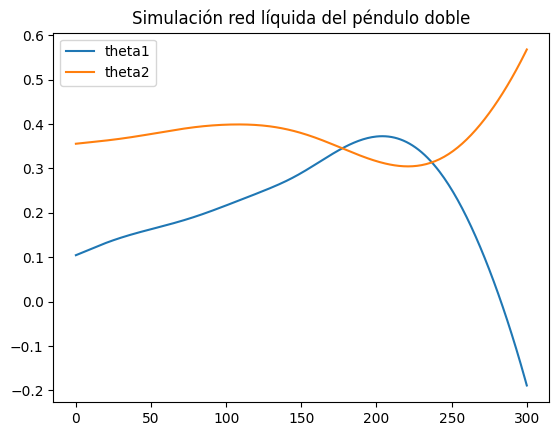

In [7]:
plt.plot(traj[:, 0], label="theta1")
plt.plot(traj[:, 1], label="theta2")
plt.legend()
plt.title("Simulación red líquida del péndulo doble")